# Biases: CESM3 / MOM6 experiment comparison

Additional bias diagnostics for a set of coupled and forced experiments,
beyond the ones already covered in `key_diagnostics.ipynb`. The shared
`Experiment` class lives in `experiment.py` so it can be reused across
notebooks.

**Experiments compared**

| name | mode | data folder |
|------|------|-------------|
| `CTRL` | coupled | `data/coupled_55years` |
| `coupled_bANN_1.0` | coupled | `data/coupled_55years` |
| `coupled_bANN_1.0_uANN_1.0` | coupled | `data/coupled_55years` |
| `forced_CTRL` | forced | `data/forced_55years` |
| `forced_bANN_1.0` | forced | `data/forced_55years` |
| `forced_bANN_1.0_uANN_1.0` | forced | `data/forced_55years` |

**Kernel:** `env-from-npl-2024a` (Python 3.11.6).

In [2]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

import os

import numpy as np
import matplotlib.pyplot as plt
import cftime

from experiment import Experiment

plt.rcParams['figure.figsize'] = (15, 5)
plt.rcParams.update({'font.size': 18})

# Repo-root-relative paths (this notebook lives in <repo>/notebooks)
REPO = os.path.abspath(os.path.join(os.getcwd(), '..'))
YAML_DIR = os.path.join(REPO, 'yamls')
COUPLED_DIR = os.path.join(REPO, 'data', 'coupled_55years')
FORCED_DIR = os.path.join(REPO, 'data', 'forced_55years')
FIG_DIR = os.path.join(REPO, 'figures', 'coupled_55years')

print('REPO       =', REPO)
print('YAML_DIR   =', YAML_DIR)
print('COUPLED_DIR=', COUPLED_DIR)
print('FORCED_DIR =', FORCED_DIR)

REPO       = /glade/u/home/pavelp/m2lines-CESM3-diagnostics
YAML_DIR   = /glade/u/home/pavelp/m2lines-CESM3-diagnostics/yamls
COUPLED_DIR= /glade/u/home/pavelp/m2lines-CESM3-diagnostics/data/coupled_55years
FORCED_DIR = /glade/u/home/pavelp/m2lines-CESM3-diagnostics/data/forced_55years


## Initialize experiments (read-only)

Each experiment is defined by its `name`, the diagnostics YAML config, and the
folder holding its postprocessed NetCDF files. Initialization is read-only: it
only reads config + (best-effort) grid, and never triggers heavy computation.

In [4]:
# (name, folder) for each experiment. YAML config is yamls/<name>.yaml
experiment_defs = [
    ('CTRL',                        COUPLED_DIR),
    ('coupled_bANN_1.0',            COUPLED_DIR),
    ('coupled_bANN_1.0_uANN_1.0',   COUPLED_DIR),
    ('forced_CTRL',                 FORCED_DIR),
    ('forced_bANN_1.0',             FORCED_DIR),
    ('forced_bANN_1.0_uANN_1.0',    FORCED_DIR),
]

exps = {}
for name, folder in experiment_defs:
    yaml_path = os.path.join(YAML_DIR, f'{name}.yaml')
    exps[name] = Experiment(yaml_path, folder=folder, name=name,
                            load_grid=True, verbose=True)

exp_names = list(exps.keys())
coupled_names = ['coupled_bANN_1.0', 'coupled_bANN_1.0_uANN_1.0', 'CTRL' ]
forced_names = ['forced_bANN_1.0', 'forced_bANN_1.0_uANN_1.0', 'forced_CTRL']

print('\nInitialized:', exp_names)

[CTRL] casename=CTRL, rundir=/glade/derecho/scratch/jiarongw/CTRL/run
MOM6 grid successfully loaded... 

[coupled_bANN_1.0] casename=coupled_bANN_1.0, rundir=/glade/derecho/scratch/pavelp/coupled_bANN_1.0/run
MOM6 grid successfully loaded... 

[coupled_bANN_1.0_uANN_1.0] casename=coupled_bANN_1.0_uANN_1.0, rundir=/glade/derecho/scratch/pavelp/coupled_bANN_1.0_uANN_1.0/run
MOM6 grid successfully loaded... 

[forced_CTRL] casename=forced_CTRL, rundir=/glade/derecho/scratch/pavelp/forced_CTRL/run
MOM6 grid successfully loaded... 

[forced_bANN_1.0] casename=forced_bANN_1.0, rundir=/glade/derecho/scratch/pavelp/forced_bANN_1.0/run
MOM6 grid successfully loaded... 

[forced_bANN_1.0_uANN_1.0] casename=forced_bANN_1.0_uANN_1.0, rundir=/glade/derecho/scratch/pavelp/forced_bANN_1.0_uANN_1.0/run
MOM6 grid successfully loaded... 


Initialized: ['CTRL', 'coupled_bANN_1.0', 'coupled_bANN_1.0_uANN_1.0', 'forced_CTRL', 'forced_bANN_1.0', 'forced_bANN_1.0_uANN_1.0']


In [5]:
# Short legend labels (regime is shown in the panel title, so it is omitted here)
LABELS = {
    'CTRL':                       'GM',
    'coupled_bANN_1.0':           'bANN',
    'coupled_bANN_1.0_uANN_1.0':  'bANN_uANN',
    'forced_CTRL':                'GM',
    'forced_bANN_1.0':            'bANN',
    'forced_bANN_1.0_uANN_1.0':   'bANN_uANN',
}

# 1. Temperature bias (model - obs)

Time-mean potential temperature bias against the WOA-2018 climatology
(`woa-2018-tx2_3v2-annual-all`), read directly from the precomputed
`thetao_bias` field in each experiment's `*_thetao_time_mean.nc`
(`model - obs`, generated by `mom6_tools.TS_levels`; see
[compare_runs_coupled.ipynb](../notebooks-development/compare_runs_coupled.ipynb)
for the original ad hoc version of this bias computation). Shown at the
surface level (`z_l` = 2.5 m). RMSE is the area-weighted RMS of the bias field
(`mom6_tools.m6plot.myStats`).

Same 2x3 grid / contourf / gray-land / shared-colorbar spatial-map style as
key_diagnostics.ipynb section 11 (surface epineutral diffusivity).

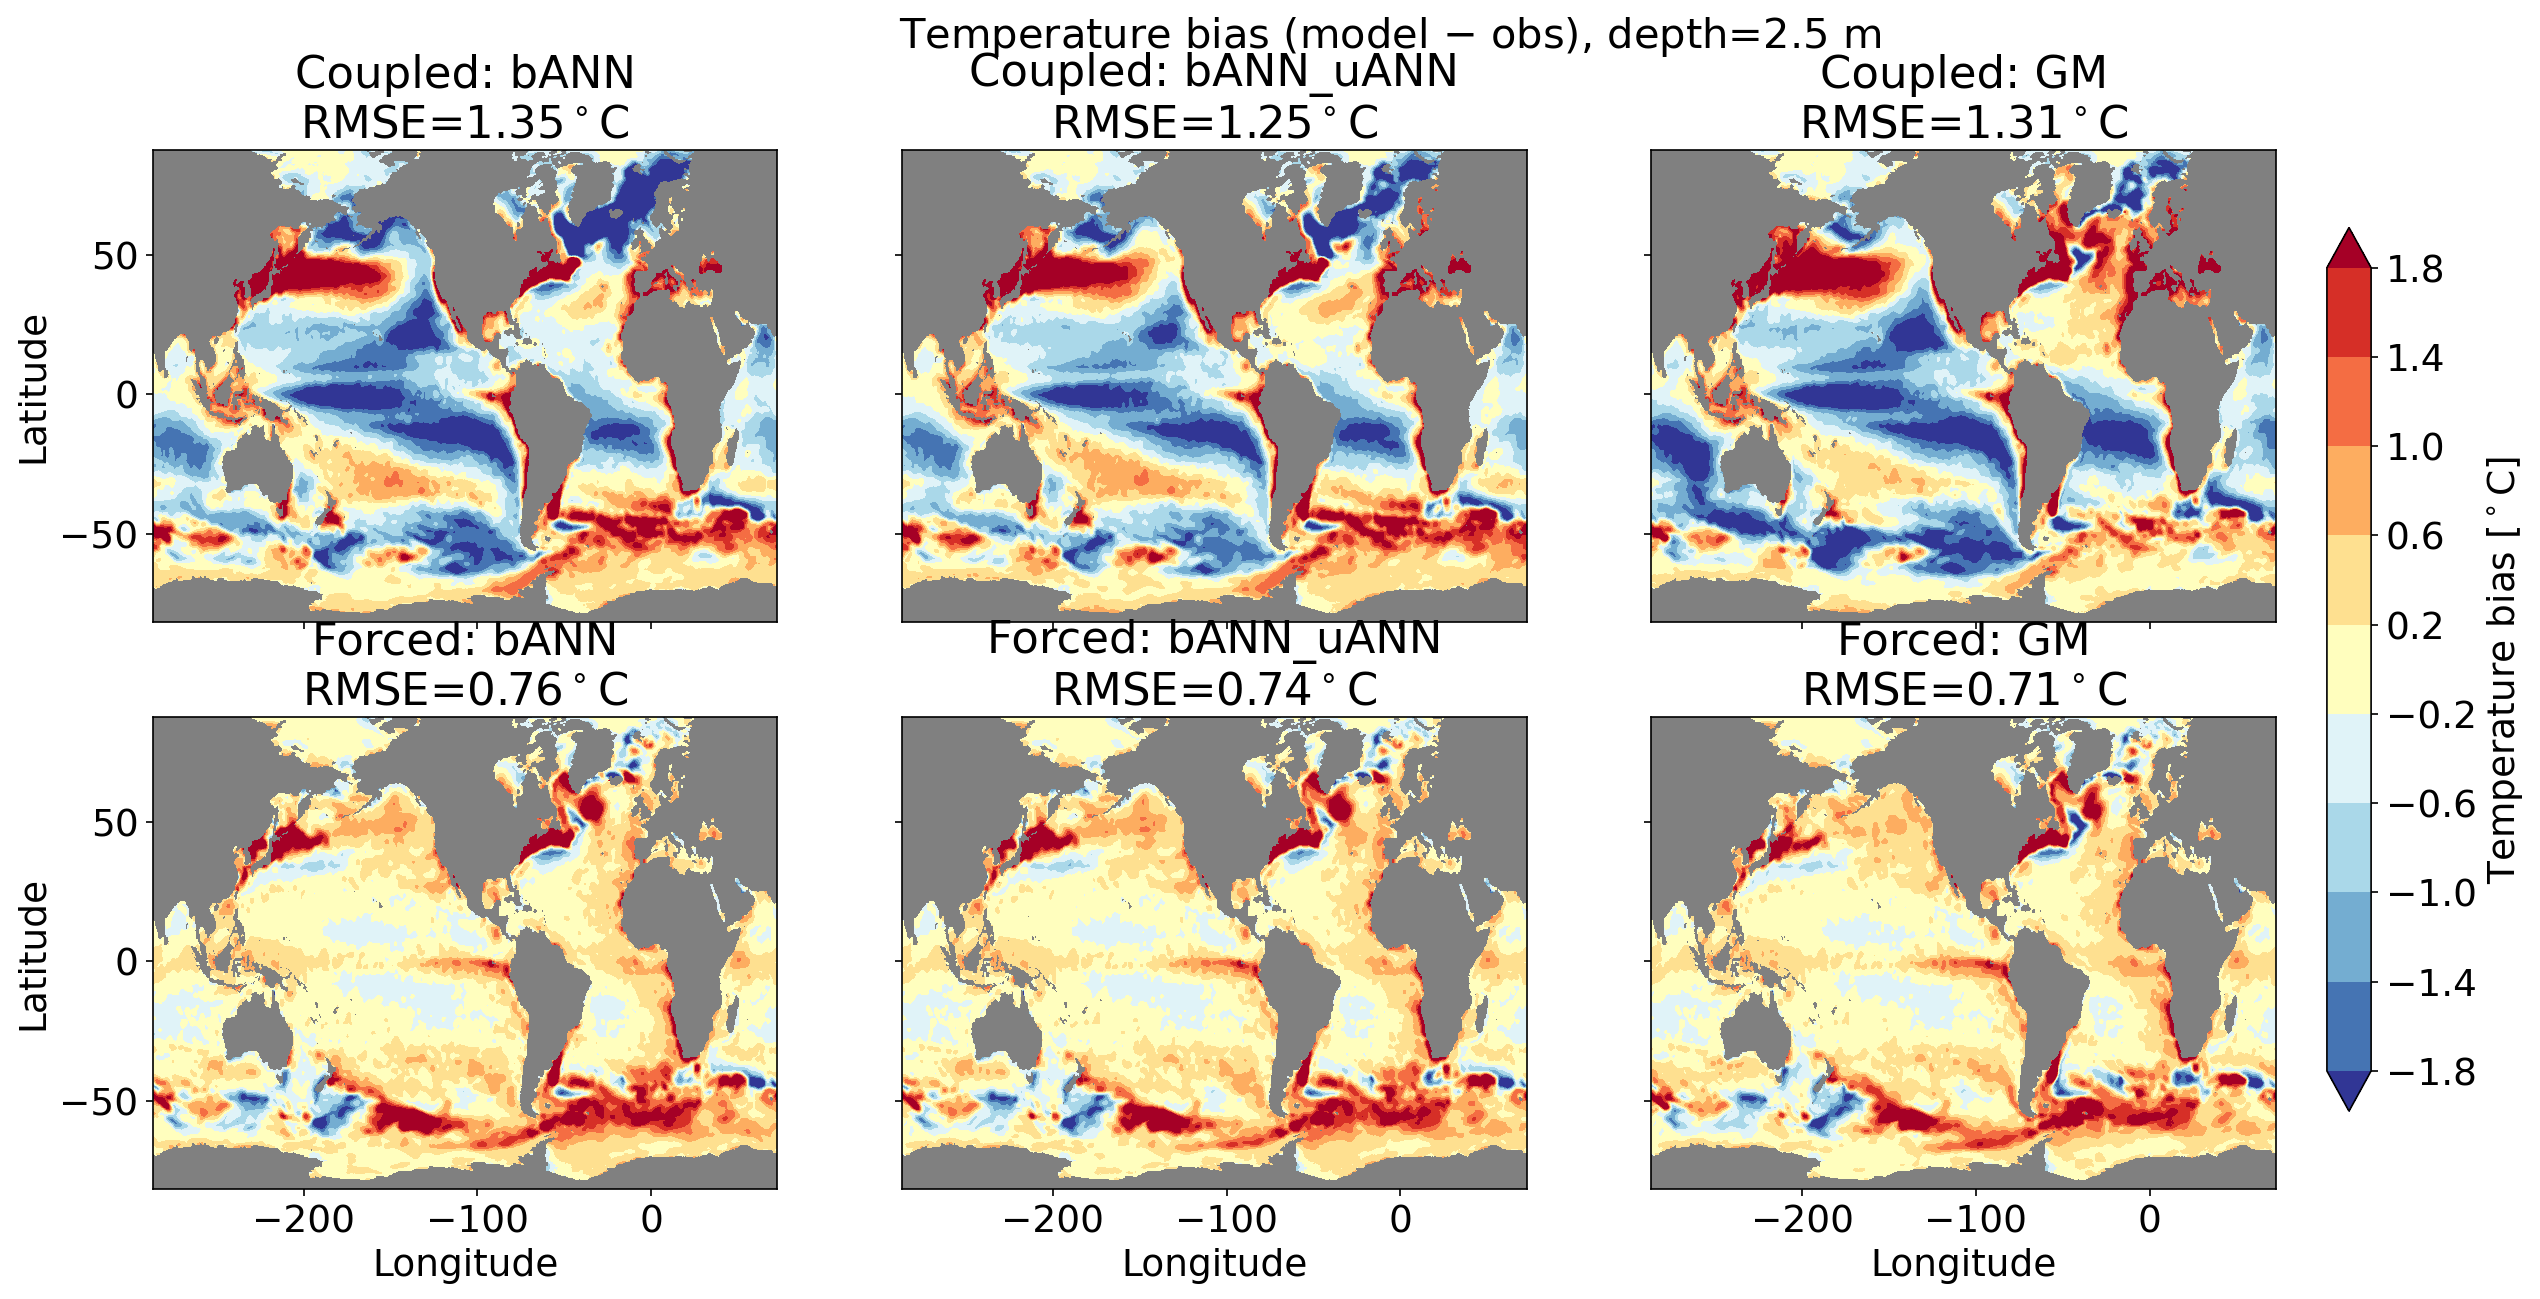

In [9]:
# Surface temperature bias maps: 2x3 grid (coupled top / forced bottom).
%matplotlib inline
from mom6_tools.m6plot import myStats

KLEVEL = 0                              # surface (z_l = 2.5 m)
TBIAS_LEVELS = np.arange(-1.8, 1.81, 0.4)   # degC, matches compare_runs_coupled.ipynb

fig, axes = plt.subplots(2, 3, figsize=(22, 9), dpi=150,
                         sharex=True, sharey=True)
cf = None
depth = None
for row, (regime, names) in enumerate([('Coupled', coupled_names),
                                       ('Forced', forced_names)]):
    for col, name in enumerate(names):
        ax = axes[row, col]
        exp = exps[name]
        bias = exp.thetao().thetao_bias.isel(z_l=KLEVEL)
        depth = round(float(bias.z_l), 1)
        area = np.ma.masked_invalid(exp.area)
        _, _, _, _, rmse = myStats(np.ma.masked_invalid(bias.values), area)
        cf = bias.plot.contourf(ax=ax, x='xh', y='yh', levels=TBIAS_LEVELS,
                                cmap='RdYlBu_r', extend='both', add_colorbar=False)
        ax.set_facecolor('gray')
        ax.set_title(f'{regime}: {LABELS[name]}\nRMSE={rmse:.2f}' + r'$^\circ$C')
        ax.set_xlabel('Longitude' if row == 1 else '')
        ax.set_ylabel('Latitude' if col == 0 else '')
fig.colorbar(cf, ax=axes, label=r'Temperature bias [$^\circ$C]',
             extend='both', shrink=0.85, pad=0.02)
fig.suptitle(f'Temperature bias (model $-$ obs), depth={depth} m',
            fontsize=20)
plt.show()